 k  Error (2D)  Error (100D with 98 Noise)
 1         0.0                    0.366667
 3         0.0                    0.300000
 5         0.0                    0.366667
 7         0.0                    0.400000
 9         0.0                    0.433333


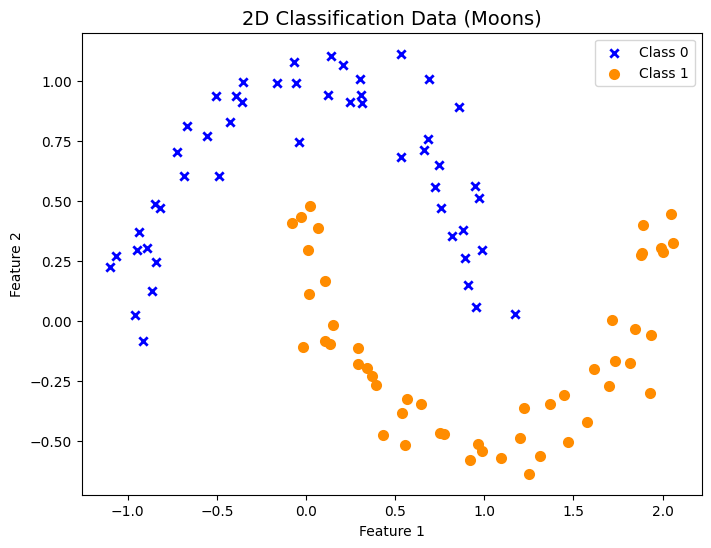

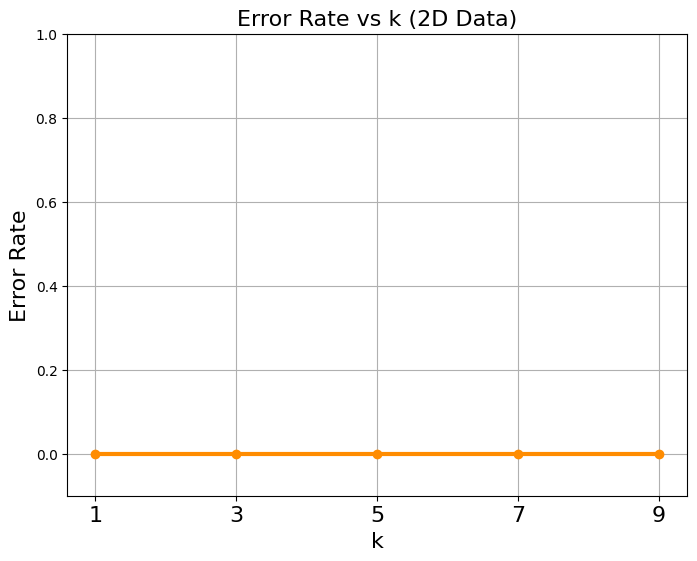

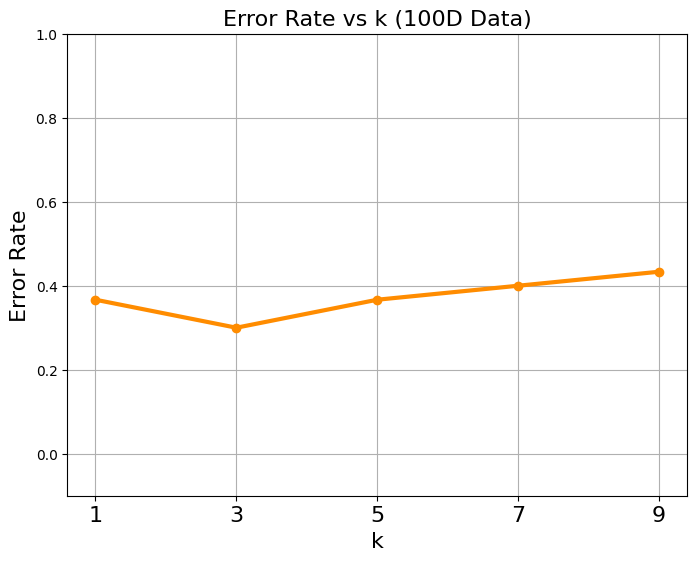

In [39]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# -----------------------------------------
# Original Color Palette
# -----------------------------------------
color_palette = {
    "white": "#FFFFFF",
    "light_gray": "#D3D3D3",
    "gray": "#808080",
    "black": "#000000",
    "green": "#008000",
    "blue": "#0000FF",
    "light_blue": "#ADD8E6",
    "light_light_blue": "#E0FFFF",
    "yellow": "#FFFF00",
    "orange": "#FFA500",
    "dark_orange": "#FF8C00",
    "purple": "#800080",
}

# Fix randomness for reproducibility
np.random.seed(0)

# -----------------------------------------
# Data Generation Function
# -----------------------------------------
def generate_data(n_samples=100):
    X, y = make_moons(n_samples=n_samples, noise=0.1, random_state=0)
    return X, y

# -----------------------------------------
# Add Noise Features Function
# -----------------------------------------
def add_noise_features(X, n_noise_features=98):
    noise = np.random.randn(X.shape[0], n_noise_features)
    return np.hstack((X, noise))

# -----------------------------------------
# Prepare Data
# -----------------------------------------
X, y = generate_data(n_samples=100)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)

# Noisy (100-dimensional) data
X_noisy = add_noise_features(X)
X_noisy_train, X_noisy_test, _, _ = train_test_split(
    X_noisy, y, test_size=0.3, random_state=0)

# -----------------------------------------
# k-NN Evaluation Function
# -----------------------------------------
def evaluate_knn(X_train, X_test, y_train, y_test, n_neighbors):
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    error_rate = 1 - accuracy_score(y_test, y_pred)
    return error_rate

# -----------------------------------------
# Evaluate multiple k-values and output results as a table
# -----------------------------------------
results = []
k_values = range(1, 11, 2)

for k in k_values:
    error_2d = evaluate_knn(X_train, X_test, y_train, y_test, k)
    error_100d = evaluate_knn(X_noisy_train, X_noisy_test, y_train, y_test, k)
    results.append([k, error_2d, error_100d])

# Display results table
results_df = pd.DataFrame(results, columns=["k", "Error (2D)", "Error (100D with 98 Noise)"])
print(results_df.to_string(index=False))

# -----------------------------------------
# Plot (2D data clearly with specified markers/colors)
# -----------------------------------------
plt.figure(figsize=(8, 6))
for class_value, marker, color in zip(
        [0, 1], ['x', 'o'], [color_palette["blue"], color_palette["dark_orange"]]):
    plt.scatter(
        X[y == class_value, 0],
        X[y == class_value, 1],
        label=f"Class {class_value}",
        marker=marker,
        color=color,
        linewidths=2
    )

plt.title("2D Classification Data (Moons)", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
# plt.grid(False)
plt.show()

fontsize = 16
# Plot Error Rates vs k (2D Data)
plt.figure(figsize=(8, 6))
plt.plot(results_df["k"], results_df["Error (2D)"],
         color=color_palette["dark_orange"], linewidth=3, marker='o')
plt.title("Error Rate vs k (2D Data)", fontsize=fontsize)
plt.xlabel("k", fontsize=fontsize)
plt.ylabel("Error Rate", fontsize=fontsize)
plt.xticks(results_df["k"], fontsize=fontsize)
plt.ylim(-.1, 1)
plt.grid(True)
plt.show()

# Plot Error Rates vs k (100D Data with Noise)
plt.figure(figsize=(8, 6))
plt.plot(results_df["k"], results_df["Error (100D with 98 Noise)"],
         color=color_palette["dark_orange"], linewidth=3, marker='o')
plt.title("Error Rate vs k (100D Data)", fontsize=fontsize)
plt.xlabel("k", fontsize=fontsize)
plt.ylabel("Error Rate", fontsize=fontsize)
plt.xticks(results_df["k"], fontsize=fontsize)
plt.ylim(-.1, 1)
plt.grid(True)
plt.show()

In [9]:
print("X_train")
print(X_train[:10])

print("X_train_noisy (first 2 dimensions)")
print(X_noisy_train[:10, :2])

X_train
[[ 0.71546319  0.52124465]
 [ 0.22632502  0.32059121]
 [ 2.23853406  0.39966354]
 [-0.8350772   0.28160596]
 [-0.44610008  0.67927185]
 [-1.26041164 -0.15603582]
 [ 0.32821109  0.4086459 ]
 [-0.87345901  0.39102738]
 [ 0.72155816 -0.71456451]
 [-0.67921922  0.73657615]]
X_train_noisy (first 2 dimensions)
[[ 0.71546319  0.52124465]
 [ 0.22632502  0.32059121]
 [ 2.23853406  0.39966354]
 [-0.8350772   0.28160596]
 [-0.44610008  0.67927185]
 [-1.26041164 -0.15603582]
 [ 0.32821109  0.4086459 ]
 [-0.87345901  0.39102738]
 [ 0.72155816 -0.71456451]
 [-0.67921922  0.73657615]]
